Device: cpu
Loading real FordA time series dataset...

--- Pre-training with Self-Supervised Learning ---
Epoch 01/15 | Contrastive Loss: 0.6772
Epoch 02/15 | Contrastive Loss: 0.2497
Epoch 03/15 | Contrastive Loss: 0.1799
Epoch 04/15 | Contrastive Loss: 0.1326
Epoch 05/15 | Contrastive Loss: 0.1167
Epoch 06/15 | Contrastive Loss: 0.1105
Epoch 07/15 | Contrastive Loss: 0.1014
Epoch 08/15 | Contrastive Loss: 0.0792
Epoch 09/15 | Contrastive Loss: 0.0902
Epoch 10/15 | Contrastive Loss: 0.0850
Epoch 11/15 | Contrastive Loss: 0.0812
Epoch 12/15 | Contrastive Loss: 0.0802
Epoch 13/15 | Contrastive Loss: 0.0832
Epoch 14/15 | Contrastive Loss: 0.0702
Epoch 15/15 | Contrastive Loss: 0.0719

FINAL EVALUATION ON DOWNSTREAM TEST
Classifier Accuracy (Raw Data): 48.00%
Classifier Accuracy (SSL Features): 84.00%


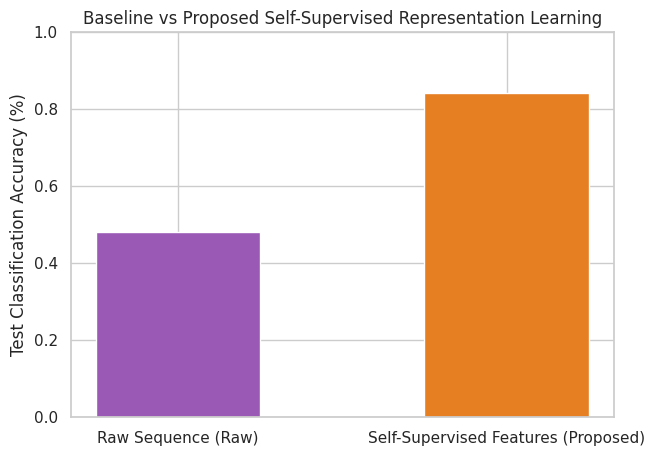

In [ ]:

# ==========================================
# Setup
# ==========================================

import os  # system tools
import warnings  # silence warnings
import urllib.request  # download files
import numpy as np  # fast math
import pandas as pd  # data tables
import torch  # deep learning
import torch.nn as nn  # neural layers
import torch.optim as optim  # weight adjusters
import torch.nn.functional as F  # math functions
from torch.utils.data import Dataset, DataLoader  # batch handlers
import matplotlib.pyplot as plt  # plot graphs
import seaborn as sns  # plot styling
from sklearn.manifold import TSNE  # visual clustering
from sklearn.model_selection import train_test_split  # split generator
from sklearn.linear_model import LogisticRegression  # simple classifier
from sklearn.metrics import accuracy_score  # score accuracy

warnings.filterwarnings('ignore')  # hide warnings

SEED = 42  # standard seed
torch.manual_seed(SEED)  # seed pytorch
np.random.seed(SEED)  # seed numpy

# ==========================================
# Dataset Loader
# ==========================================

class TimeSeriesDataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.FloatTensor(data).unsqueeze(1)  # float tensor with channel - Unsqueeze(1): Adds channel dimension at position 1 - converts (batch, length) to (batch, channels=1, length) for Conv1d input.
        self.labels = torch.LongTensor(labels)  # integer labels - LongTensor: Converts labels to 64-bit integers - required for cross-entropy loss.

    def __len__(self):
        return len(self.data)  # sample count

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]  # get single sample

def load_real_timeseries():
    # FordA dataset url paths
    train_url = "https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/FordA_TRAIN.tsv"
    test_url = "https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/FordA_TEST.tsv"

    # read datasets
    train_df = pd.read_csv(train_url, sep='\t', header=None)
    test_df = pd.read_csv(test_url, sep='\t', header=None)

    # subset samples for faster run
    train_df = train_df.sample(n=min(600, len(train_df)), random_state=SEED) # Sample: Randomly selects up to 600 samples - reduces dataset size for faster experimentation while maintaining reproducibility.
    test_df = test_df.sample(n=min(200, len(test_df)), random_state=SEED) # Sample: Randomly selects up to 200 samples - reduces test set for quick evaluation while keeping reproducibility.

    # slice features and labels
    X_train = train_df.iloc[:, 1:].values # iloc[:, 1:]: Selects all rows, columns from index 1 onward - extracts features, dropping the first column (labels).
    y_train = train_df.iloc[:, 0].values # iloc[:, 0]: Selects all rows, first column only - extracts target labels (class values).
    X_test = test_df.iloc[:, 1:].values # iloc[:, 1:]: Selects all rows, columns from index 1 onward - extracts test features, dropping labels column.
    y_test = test_df.iloc[:, 0].values # iloc[:, 0]: Selects all rows, first column only - extracts test target labels.

    # map targets to clean labels
    y_train = np.where(y_train == -1, 0, 1) # Map Labels: Converts -1 to 0 and 1 stays 1 - standardizes binary labels for classification (0/1 instead of -1/1).
    y_test = np.where(y_test == -1, 0, 1) # Map Labels: Converts -1 to 0, keeps 1 as 1 - standardizes test labels to 0/1 format for evaluation.

    return X_train, y_train, X_test, y_test  # return datasets

# ==========================================
# Data Augmentation
# ==========================================

def temporal_augment(x, max_shift=15, noise_level=0.15):
    batch_size, channels, length = x.shape  # unpack shape
    shift = np.random.randint(-max_shift, max_shift)  # random shift amount

    # perform shifting
    if shift > 0:
        x_aug = torch.cat([x[:, :, shift:], torch.zeros(batch_size, channels, shift, device=x.device)], dim=-1) # Shift Right + Pad: Drops first shift elements and pads zeros at end - shifts sequence right, filling missing positions with zeros.
    elif shift < 0:
        x_aug = torch.cat([torch.zeros(batch_size, channels, -shift, device=x.device), x[:, :, :shift]], dim=-1) # Shift Left + Pad: Drops last shift elements and pads zeros at start - shifts sequence left, filling missing positions with zeros.
    else:
        x_aug = x.clone() # Clone: Creates a copy of the original tensor - used when no shift is applied, preserving the unchanged sequence.

    # add noise
    noise = torch.randn_like(x_aug) * noise_level # Gaussian Noise: Generates random normal noise same shape as input, scaled by noise_level - adds variability for augmentation robustness.
    return x_aug + noise  # return augmented input

# ==========================================
# Neural Network Models
# ==========================================

class TemporalEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=8, padding='same')  # layer 1
        self.bn1 = nn.BatchNorm1d(32)  # normalize 1
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding='same')  # layer 2
        self.bn2 = nn.BatchNorm1d(64)  # normalize 2
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding='same')  # layer 3
        self.bn3 = nn.BatchNorm1d(128)  # normalize 3
        self.pool = nn.AdaptiveAvgPool1d(1)  # mean pooling

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))  # process block 1
        x = F.relu(self.bn2(self.conv2(x)))  # process block 2
        x = F.relu(self.bn3(self.conv3(x)))  # process block 3
        x = self.pool(x)  # aggregate features
        return x.squeeze(-1)  # squeeze dimension

class ProjectionHead(nn.Module):
    def __init__(self, in_dim=128, hidden_dim=64, out_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),  # map hidden
            nn.BatchNorm1d(hidden_dim),  # normalize
            nn.ReLU(),  # activate
            nn.Linear(hidden_dim, out_dim)  # map projection
        )  # layers stack

    def forward(self, x):
        return self.net(x)  # extract projection

# ==========================================
# Loss Function (Contrastive InfoNCE)
# ==========================================

def info_nce_loss(z1, z2, temperature=0.1):
    batch_size = z1.shape[0]  # get batch size integer (FIXED)
    z1 = F.normalize(z1, dim=-1)  # normalize vector 1
    z2 = F.normalize(z2, dim=-1)  # normalize vector 2

    logits = torch.matmul(z1, z2.T) / temperature  # similarities matrix
    labels = torch.arange(batch_size, device=z1.device)  # identity labels

    loss_1 = F.cross_entropy(logits, labels)  # alignment loss 1
    loss_2 = F.cross_entropy(logits.T, labels)  # alignment loss 2
    return (loss_1 + loss_2) / 2.0  # symmetric loss

# ==========================================
# Training Pipeline
# ==========================================

def run_temporal_ssl():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # check processor
    print(f"Device: {device}")  # print device

    print("Loading real FordA time series dataset...")  # log status
    try:
        X_train, y_train, X_test, y_test = load_real_timeseries()  # try real dataset
    except Exception as e:
        print(f"Failed to fetch data: {e}. Generating synthetic backup instead...")  # log error
        X_train = np.random.randn(200, 100)  # fake train inputs
        y_train = np.random.randint(0, 2, 200)  # fake train targets
        X_test = np.random.randn(100, 100)  # fake test inputs
        y_test = np.random.randint(0, 2, 100)  # fake test targets

    train_dataset = TimeSeriesDataset(X_train, y_train)  # wrap dataset
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)  # load batches

    encoder = TemporalEncoder().to(device)  # init encoder
    projection_head = ProjectionHead().to(device)  # init projector

    optimizer = optim.Adam(list(encoder.parameters()) + list(projection_head.parameters()), lr=0.001)  # init optimizer

    print("\n--- Pre-training with Self-Supervised Learning ---")  # log status
    encoder.train()  # set training
    projection_head.train()  # set training

    for epoch in range(15):  # loop epochs
        total_loss = 0  # epoch tracker
        for x, _ in train_loader:  # loop batches
            x = x.to(device)  # send hardware
            x_aug1 = temporal_augment(x)  # generate view 1
            x_aug2 = temporal_augment(x)  # generate view 2

            z1 = projection_head(encoder(x_aug1))  # project view 1
            z2 = projection_head(encoder(x_aug2))  # project view 2

            loss = info_nce_loss(z1, z2)  # compute loss

            optimizer.zero_grad()  # zero variables
            loss.backward()  # backpropagation
            optimizer.step()  # update weights
            total_loss += loss.item()  # accumulate tracker

        print(f"Epoch {epoch+1:02d}/15 | Contrastive Loss: {total_loss/len(train_loader):.4f}")  # print loss

    # ==========================================
    # Feature Extraction & Linear Evaluation
    # ==========================================

    encoder.eval()  # freeze architecture

    # Extract training embeddings
    train_embeddings = []
    with torch.no_grad():
        for x, _ in DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=64, shuffle=False): 
            feats = encoder(x.to(device))
            train_embeddings.append(feats.cpu().numpy())
    train_embeddings = np.concatenate(train_embeddings, axis=0)  # concatenate train

    # Extract testing embeddings
    test_embeddings = []
    with torch.no_grad():
        for x, _ in DataLoader(TimeSeriesDataset(X_test, y_test), batch_size=64, shuffle=False):
            feats = encoder(x.to(device))
            test_embeddings.append(feats.cpu().numpy())
    test_embeddings = np.concatenate(test_embeddings, axis=0)  # concatenate test

    # Train Logistic Regression on RAW timeseries
    clf_raw = LogisticRegression(max_iter=1000)
    clf_raw.fit(X_train, y_train)  # train classifier
    acc_raw = accuracy_score(y_test, clf_raw.predict(X_test))  # score accuracy

    # Train Logistic Regression on LEARNED representations
    clf_ssl = LogisticRegression(max_iter=1000)
    clf_ssl.fit(train_embeddings, y_train)  # train classifier
    acc_ssl = accuracy_score(y_test, clf_ssl.predict(test_embeddings))  # score accuracy

    print("\n=====================================")
    print("FINAL EVALUATION ON DOWNSTREAM TEST")
    print("=====================================")
    print(f"Classifier Accuracy (Raw Data): {acc_raw * 100:.2f}%")  # display baseline
    print(f"Classifier Accuracy (SSL Features): {acc_ssl * 100:.2f}%")  # display proposed
    print("=====================================")

    # Plot performance bar chart comparison
    sns.set_theme(style="whitegrid")  # set theme
    plt.figure(figsize=(7, 5))  # canvas size
    plt.bar(['Raw Sequence (Raw)', 'Self-Supervised Features (Proposed)'], [acc_raw, acc_ssl], color=['#9b59b6', '#e67e22'], width=0.5)  # draw bars
    plt.ylabel('Test Classification Accuracy (%)')  # y label
    plt.title('Baseline vs Proposed Self-Supervised Representation Learning')  # plot title
    plt.ylim(0, 1.0)  # y limits
    plt.show()  # display plot

if __name__ == '__main__':
    run_temporal_ssl()  # run script